<a href="https://colab.research.google.com/github/NahomKidane/ai301-labs/blob/main/m03-embeddings/challenge-labs/AI301_M03_Challenge_Lab_01_v3_Probing_Contextual_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 301 - Challenge Lab 01: Probing Contextual Embeddings

**Course:** AI 301 - Natural Language Processing and Conversational AI
**Notebook:** Challenge Lab 01, Module 3, what a contextual embedding knows and what it inherits
**Student:** ____________________   **Date:** _____________

In this assignment, you will:

- Train a word2vec model yourself and say what each training setting does
- Build four small vectors by hand to see what cosine similarity does and does not measure
- Read a word's vector out of BERT from inside a sentence, and compare it with the model's own
  lookup row and with your word2vec vector for the same word
- Find a word with two meanings and show how far apart BERT puts them
- Find a case where an antonym sits closer than a synonym, and explain it
- Measure an association the model has absorbed, against a control group, and set it beside the
  workforce figures it is often assumed to reflect

You will not implement an algorithm from scratch. The one model you train is word2vec, on a corpus
you have already met.

Work through Guided Labs Part 1 to Part 3 before you start, and keep them open while you work.
Every function you write here has a worked version in one of them.

How the notebook works:

- Each section first defines a function, then calls it in the next cell
- New Python ideas are explained in notes marked **Python note**. Skip any that cover something you
  already know.

## Submission

Work in your own copy of this notebook (File > Save a copy in Drive). Download it with
File > Download > Download .ipynb and upload to Canvas as
`AI301_Challenge_Lab_01_FirstName_LastName.ipynb`. All cells run, outputs visible, name and date at
the top, and an answer under each required exercise.

The due date is on the Canvas assignment page.

## Grading (100 points)

- Exercise 1: 15 points
- Exercise 2: 5 points
- Exercise 3: 15 points
- Exercise 4: 15 points
- Exercise 5: 10 points
- Exercise 6: 25 points
- Final Reflection: 15 points, written, no code

For each exercise: code run with your own inputs, outputs visible, and analysis specific to your own
outputs. 

## 1. Setup

Save a copy before you start, File > Save a copy in Drive, and work in your copy.

Switch on the T4, Runtime > Change runtime type > T4 GPU. This lab loads `bert-base-cased`, about 400
megabytes of weights, and `text8`, a 31.6 MB corpus you train word2vec on in about a minute.
Both are cached for the rest of the session. Nothing here generates text.

In [ ]:
!pip install -q transformers "gensim>=4.4"

In [ ]:
import warnings
warnings.filterwarnings("ignore")           # keep the output readable

import numpy as np                          # arrays, means and norms
import pandas as pd                         # the tables this notebook prints
import matplotlib.pyplot as plt              # the chart in Exercise 6
import torch                                # the numeric library BERT is built on

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()            # silence the loading report, it is not an error
from transformers import AutoTokenizer      # the model's own tokenizer
from transformers import AutoModel          # the model, no task head

import gensim.downloader as api             # fetches the text8 corpus
from gensim.models import Word2Vec          # the trainer from Parts 2 and 3
from gensim.models.word2vec import Text8Corpus   # reads text8 as chunks of 10,000 tokens

print("imports ready")

Load the tokenizer and the model. You did this in Part 1.

In [ ]:
REPOSITORY = "bert-base-cased"


def load_models():
    # TODO: load the tokenizer and the model for REPOSITORY
    # hint: both classes above take a repository name through the same method
    tokenizer = ____________________
    model = ____________________
    return tokenizer, model


try:
    tokenizer, model = load_models()
    static_matrix = model.get_input_embeddings().weight
    print("vocabulary:", tokenizer.vocab_size)
    print("static embedding matrix:", tuple(static_matrix.shape))
except (NameError, AttributeError, TypeError):
    print("Fill in the blanks above, then run this cell again.")

> Model card: [bert-base-cased](https://huggingface.co/google-bert/bert-base-cased). Read it for the
> casing and the corpus, since both decide what these vectors know.

`static_matrix` is the lookup table from Part 1, one row per token, no sentence involved.

## 2. Train word2vec

Parts 2 and 3 of the guided labs trained word2vec for you. Here you write the training call yourself,
so the settings are yours to choose and explain. The corpus loop is given: it reads the first 200
chunks of `text8`, two million tokens.

`text8` is the first 100 million characters of a 2006 English Wikipedia dump, cleaned to lowercase
letters and spaces, about 17 million words. It is the corpus Part 3 used.
[gensim-data, text8](https://github.com/piskvorky/gensim-data#text8).

Every setting below is an argument to `Word2Vec`. The middle column is what Part 3 used.

| setting | Part 3 | what it does |
|---|---|---|
| `sentences` | the list from the loop | the corpus, one list of tokens per chunk |
| `vector_size` | 100 | how many numbers each word vector has. More can hold finer distinctions and costs time and data |
| `window` | 5 | how many words either side count as context. Small windows learn what a word is, large windows learn what it is about |
| `min_count` | 5 | words seen fewer times than this get no vector at all, which is why rare words go missing |
| `sg` | 1 | 1 is skip gram, predict the neighbours from the word. 0 is CBOW, predict the word from its neighbours |
| `negative` | 5 | how many random wrong neighbours each real one is contrasted with during training |
| `epochs` | 5 | passes over the corpus. More passes move the vectors further from their random start |
| `seed` | 123 | the random start. Same seed, same result, as long as `workers` is 1 |
| `workers` | 1 | threads. More is faster and makes the run unrepeatable, so it stays at 1 here |

- **Python note:** a function call with many settings is written as `name(value, setting=value,
  setting=value)`, one setting per line if it helps you read it. Only `sentences` goes first without a
  name.

## ✏️ EXERCISE 1 (15 points)

1. Write the `Word2Vec` call inside `train_word2vec`, using the Part 3 settings from the table.
2. Run the cell. It prints the vocabulary size, the number of words that survived `min_count`.
3. Change `min_count` to 20, run again, and note the new vocabulary size. Then put it back to 5.

Analysis: give both vocabulary sizes and say why the second is smaller. Then pick two other settings
from the table and say, for each, what you would expect to change in the vectors if you doubled it.

In [ ]:
path = api.load("text8", return_path=True)
sentences = []
count = 0
for sentence in Text8Corpus(path):
    sentences.append(sentence)
    count = count + 1
    if count == 200:
        break
print("chunks:", len(sentences), "  words in the first chunk:", len(sentences[0]))
print("first 40 words:", " ".join(sentences[0][:40]))

In [ ]:
def train_word2vec(sentences):
    # TODO: the Word2Vec call, with the sentences first and then every setting from the table
    # hint: the table gives the setting names and the Part 3 values; keep seed=123 and workers=1
    return ____________________


try:
    w2v = train_word2vec(sentences)
    print("word2vec vocabulary:", len(w2v.wv.index_to_key))
except (NameError, TypeError):
    print("Fill in the blank above, then run this cell again.")

### ✍️ Write your Exercise 1 answer HERE

*Double click this cell and replace this line with your answer.*

### Representations

Three representations of every word are now available, and Exercise 5 puts them side by side.

**word2vec.** One vector per word type, the model you just trained. It learns by prediction, either
predicting a word from the words around it, which is CBOW, or predicting the surrounding words from
the word itself, which is skip gram. `bank` has one vector whichever sentence it appears in, and a
word the corpus never contained has no vector at all.

**BERT static row.** One row of BERT's lookup table, no sentence involved. This is what Part 1
printed. It is where BERT starts, before any layer runs.

**BERT contextual.** One vector per word in a particular sentence, computed by running the sentence
through the model. The same word in two sentences gives two vectors.

### The word2vec vectors are not BERT's input

A reasonable guess here is that BERT's static row is the word2vec vector. It is not. They are separate
models trained on different corpora, and BERT never sees a word2vec vector. BERT has its own
embedding table, learned during BERT's own pretraining. Feed it a sentence, it looks up each token's
row, twelve layers of attention mix in the rest of the sentence, and the contextual vector comes out
at the end.

So the two static representations are static for different reasons. word2vec's vector is the
finished model, with nothing after it. BERT's row is an unfinished starting point, since the ability
lives in the layers above it. Expect the two to disagree, and read the disagreement as information.

## 3. Cosine similarity

Every measurement in this lab is a cosine similarity, so it is worth being precise about what it is.

Think of two vectors as arrows from the origin. Cosine similarity is the cosine of the angle between
them. It says nothing about how long either arrow is, only which way each one points.

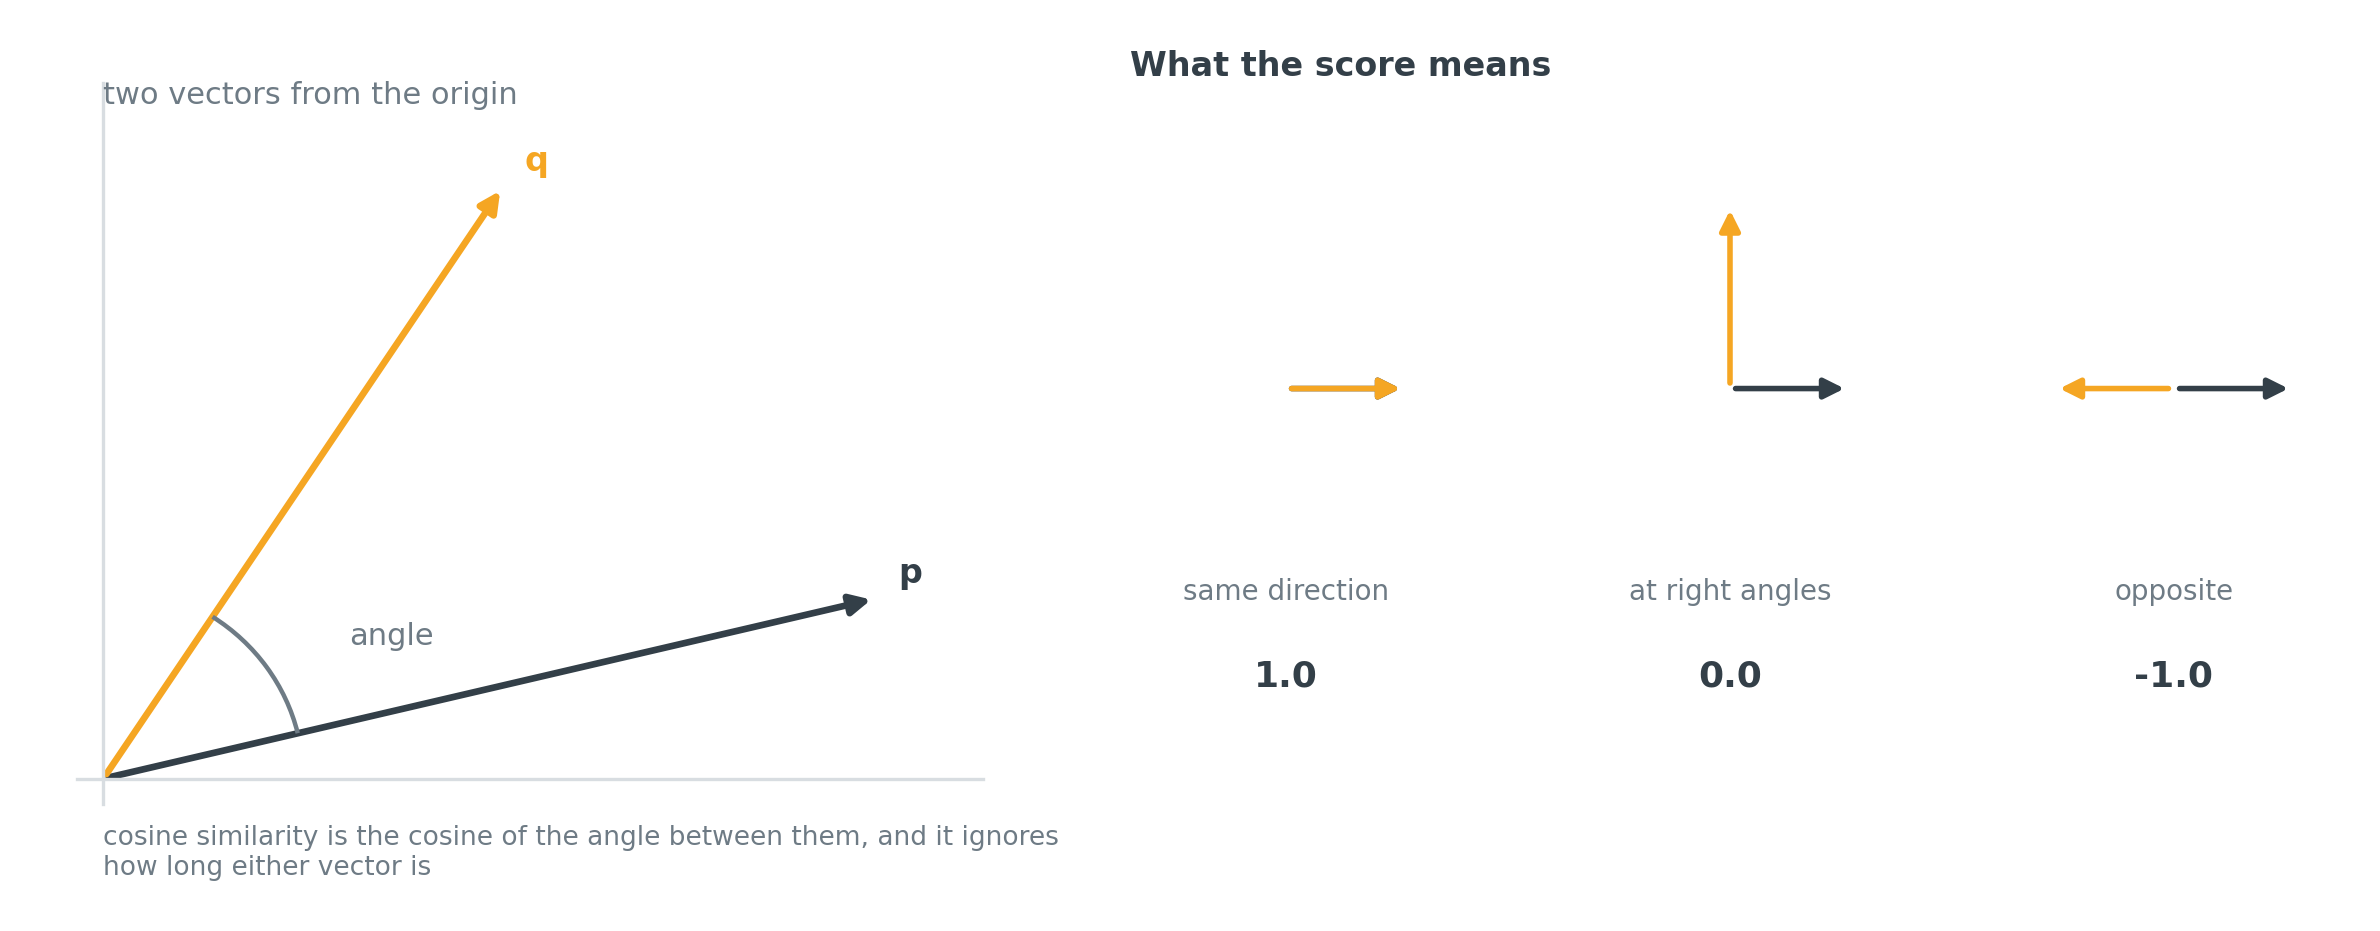

Formally, for two vectors **p** and **q**:

```
cosine(p, q) = (p . q) / (||p|| * ||q||)
```

The score lies between -1 and 1. On BERT vectors, you will rarely see anything below 0, because these
vectors sit in a narrow region of the space, so read the scores as a ranking rather than as a
percentage.

**Cosine distance** is `1 - cosine similarity`. Exercise 5 uses distance rather than similarity,
because the claim there is easier to state that way.

- **Python note:** `np.dot(a, b)` is the dot product and `np.linalg.norm(a)` is a vector's length.
  Dividing by both lengths is what removes size from the comparison, which is why a frequent word
  does not score high on everything simply because training made its vector long.

In [ ]:
def cosine(a, b):
    """Cosine similarity between two vectors."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    # TODO: the bottom of the formula, the two lengths multiplied
    # hint: np.linalg.norm of each vector
    denominator = ____________________
    if denominator == 0:
        return 0.0
    # TODO: the top of the formula divided by that
    # hint: np.dot takes the two vectors
    return float(____________________)


def distance(a, b):
    """Cosine distance, 1 minus the similarity."""
    # TODO: return the distance
    # hint: the docstring says it
    return ____________________


def show(rows):
    display(pd.DataFrame(rows))


try:
    print("a vector with itself:", round(cosine([1, 2, 3], [1, 2, 3]), 3))
    print("two vectors at right angles:", round(cosine([1, 0], [0, 1]), 3))
    print("distance between a vector and itself:", round(distance([1, 2, 3], [1, 2, 3]), 3))
except (NameError, TypeError):
    print("Fill in the blanks above, then run this cell again.")

## ✏️ EXERCISE 2 (5 points)

Before any model, four vectors by hand. Given `A = [2, 1, -3, 0]`, write each of these yourself. No
searching and no loops, and each one should take under a minute once you see it.

1. `B`, the same direction as `A` but twice as long.
2. `C`, cosine exactly 1.0 with `A`, and not equal to `A` or `B`.
3. `D`, cosine exactly -1.0 with `A`.
4. `E`, a non zero vector with cosine 0.0 with `A`.

The check cell prints all four cosines.

Analysis: In one or two sentences, say what `B` and `C` together tell you about what cosine ignores,
and what `E` tells you about what a score of zero means.

In [ ]:
A = np.array([2, 1, -3, 0])


def my_vectors():
    # TODO: B, the same direction as A, twice the length
    B = ____________________
    # TODO: C, cosine 1.0 with A, not equal to A or B
    # hint: any positive multiple points the same way
    C = ____________________
    # TODO: D, cosine -1.0 with A
    D = ____________________
    # TODO: E, non zero, cosine 0.0 with A
    # hint: pick numbers so that the dot product with A comes out to zero, one way is to use
    #       only the position where A is zero
    E = ____________________
    return np.array(B), np.array(C), np.array(D), np.array(E)


try:
    B, C, D, E = my_vectors()
    for name, vector in [("B", B), ("C", C), ("D", D), ("E", E)]:
        print(name, vector, "  cosine with A:", round(cosine(A, vector), 3))
except (NameError, TypeError):
    print("Fill in the four blanks above, then run this cell again.")

### ✍️ Write your Exercise 2 answer HERE

*Double click this cell and replace this line with your answer.*

## 4. Reading one word out of a sentence

A static vector is looked up by word. A contextual vector has to be read out of a particular
sentence, at the position where the word sits, which means finding that position first.

- **Python note:** BERT splits rare words into pieces, so `embeddings` may arrive as `embed` and
  `##dings`. The helper below returns the position of the first piece. It also lowercases nothing, since `bert-base-cased` treats `Bank` and `bank` as different
  tokens.
`model(**inputs)` and `with torch.no_grad():` are both from Part 1 and work the same way here.

In [ ]:
def find_position(text, word):
    """The position of the first token of `word` inside `text`, or None if it is not there."""
    tokens = tokenizer.tokenize(text)
    pieces = tokenizer.tokenize(word)
    for i in range(len(tokens)):
        # TODO: stop when this token is the first piece of the word
        # hint: compare tokens[i] with pieces[0]
        if ____________________:
            return i + 1        # +1 because [CLS] sits at position 0
    return None


try:
    print(tokenizer.tokenize("She deposited the cheque at the bank"))
    print("position of bank:", find_position("She deposited the cheque at the bank", "bank"))
except (NameError, TypeError):
    print("Fill in the blanks above, then run this cell again.")

## ✏️ EXERCISE 3 (15 points)

Write the two functions below.

1. `word_vector(text, word)`. Run `text` through BERT and return the contextual vector at `word`'s
   position, as a numpy array. Use `find_position`.
2. `static_vector(word)`. Return `word`'s row of `static_matrix`, as a numpy array.

Run the check cell. It puts `bank` in two sentences.

Analysis: report both similarities, and say in one sentence what the static number tells you that the
contextual number does not.

In [ ]:
def run_bert(text):
    """Runs one sentence through BERT and hands back the output."""
    # TODO: tokenize the text as pytorch tensors
    # hint: Part 1 section 3, the tokenizer takes return_tensors="pt"
    inputs = ____________________
    with torch.no_grad():
        # TODO: run the model on those inputs
        # hint: the dictionary unpacks into the call with two stars
        output = ____________________
    return output


def word_vector(text, word):
    output = run_bert(text)
    position = find_position(text, word)
    # TODO: return the vector at that position, for the first (and only) sentence, as numpy
    # hint: output.last_hidden_state is sentence by position by number, and .numpy() converts
    return ____________________


def static_vector(word):
    token_id = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(word)[0])
    # TODO: return that row of the static matrix as numpy
    # hint: index static_matrix by the id, then .detach().numpy()
    return ____________________


RIVER = "We sat on the bank and watched the water"
MONEY = "She deposited the cheque at the bank"

try:
    contextual = cosine(word_vector(RIVER, "bank"), word_vector(MONEY, "bank"))
    static = cosine(static_vector("bank"), static_vector("bank"))
    print("contextual, the two sentences:", round(contextual, 3))
    print("static, the same word twice:", round(static, 3))
    if round(static, 3) != 1.0:
        print("the static number must be exactly 1.000, so static_vector is reading the wrong thing")
    if round(contextual, 3) == 1.0:
        print("the contextual number should not be 1.000, so word_vector is not using the sentence")
except (NameError, TypeError, AttributeError):
    print("Fill in the blanks above, then run this cell again.")

### ✍️ Write your Exercise 3 answer HERE

*Cover: the two similarities the check printed, and what the static number tells you that the
contextual number does not. Double click this cell and replace this line with your answer.*

## 5. A word with two meanings

`bank` is the standard example, and you have now measured it. Let's try to see other polysemous
words (words with multiple meanings).

## ✏️ EXERCISE 4 (15 points)

1. Choose your own polysemous word, one with two clearly different meanings. Not `bank`. Candidates:
   `bat`, `spring`, `crane`, `letter`, `light`, `mine`, `pitcher`.
2. Write six short sentences, three per meaning, each containing the word.
3. Score every pair with `word_vector` and print the six by six table. The cell also prints the
   lowest across sense similarity, one number for how far apart the two meanings got.
4. Try at least two more words and keep the one with the lowest across sense similarity. Lower is
   better. Report the other words in your analysis.

Analysis:

- Name the word and its two meanings.
- State whether same meaning pairs scored higher than across meaning pairs, with the two numbers.
- Give your lowest across sense similarity, and say what the same number would be under
  `static_vector` and under your word2vec model, and why. You do not need to run it.
- Say why one word you tried did not separate. Report failures rather than hiding them.

In [ ]:
# TODO: replace these with your own word and your own six sentences
WORD = "TODO"

SENTENCES = [
    "TODO sense one, sentence one",
    "TODO sense one, sentence two",
    "TODO sense one, sentence three",
    "TODO sense two, sentence one",
    "TODO sense two, sentence two",
    "TODO sense two, sentence three",
]


def similarity_matrix(sentences, word):
    """Every sentence against every sentence, for one word."""
    rows = []
    for i in range(len(sentences)):
        row = {"sentence": str(i + 1)}
        for j in range(len(sentences)):
            row[str(j + 1)] = round(cosine(word_vector(sentences[i], word),
                                           word_vector(sentences[j], word)), 3)
        rows.append(row)
    return rows


def lowest_across(sentences, word):
    """The smallest similarity between a sense one sentence and a sense two sentence."""
    lowest = 1.0
    for i in range(3):
        for j in range(3, 6):
            score = cosine(word_vector(sentences[i], word), word_vector(sentences[j], word))
            if score < lowest:
                lowest = score
    return round(lowest, 3)


if WORD == "TODO":
    print("Choose a word and write six sentences above, then run this cell again.")
else:
    show(similarity_matrix(SENTENCES, WORD))
    print("lowest across sense similarity for", WORD + ":", lowest_across(SENTENCES, WORD))

### ✍️ Write your Exercise 4 answer HERE

*Double click this cell and replace this line with your answer.*

## 6. Synonyms and antonyms

Part 3 of the guided labs showed that static vectors score `buy` and `sell` as close as synonyms.
Antonyms sit at opposite ends of one scale and agree on everything else: `hot` and `cold` are both
temperatures, both adjectives, both used about weather and food. A single similarity score has no way
to isolate the one feature they disagree on. BERT reads the sentence, so the natural question is
whether context fixes it.

## ✏️ EXERCISE 5 (10 points)

Find three words w1, w2 and w3 where w1 and w2 are synonyms, w1 and w3 are antonyms, and

```
cosine distance(w1, w3) < cosine distance(w1, w2)
```

so the antonym sits closer than the synonym.

1. Write your three words and one test sentence with a slot, for example `The result was ____ .` Use
   the same test sentence for all three.
2. Print the two contextual distances.
3. Print them twice more, with `static_vector`, BERT's lookup row, and with `w2v_vector`, your
   word2vec model. Both ignore the sentence.

Analysis: give your three words and all six distances. Say whether the contextual measurement fixed
the problem, made it worse, or left it unchanged. Say whether the two static representations agree.
Explain what you found.

In [ ]:
# TODO: your three words and one test sentence with a slot for them
W1 = "TODO"
W2 = "TODO"     # a synonym of W1
W3 = "TODO"     # an antonym of W1
TEST_SENTENCE = "The result was WORD ."


def in_test_sentence(word):
    """Puts one word into the test sentence."""
    return TEST_SENTENCE.replace("WORD", word)


def w2v_vector(word):
    """The word2vec vector, or zeros if the model has never seen the word."""
    if word.lower() in w2v.wv:
        return w2v.wv[word.lower()]
    return np.zeros(w2v.wv.vector_size)


def compare(w1, w2, w3):
    """The same two pairs under all three representations."""
    rows = []
    for other, relation in [(w2, "synonym"), (w3, "antonym")]:
        rows.append({
            "pair": w1 + " and " + other,
            "relation": relation,
            "contextual": round(distance(word_vector(in_test_sentence(w1), w1),
                                         word_vector(in_test_sentence(other), other)), 3),
            "bert static row": round(distance(static_vector(w1), static_vector(other)), 3),
            "word2vec": round(distance(w2v_vector(w1), w2v_vector(other)), 3),
        })
    return rows


if W1 == "TODO":
    print("Choose your three words above, then run this cell again.")
else:
    show(compare(W1, W2, W3))

### ✍️ Write your Exercise 5 answer HERE

*Double click this cell and replace this line with your answer.*

## 7. What the model inherited

A model trained on written content learns the patterns within that text. This part evaluates one
example and then prompts you to find a different one.

The cell below takes a word and asks one question: is it closer to `woman` or closer to `man`? The
word goes into a test sentence, and the same test sentence is built again with `woman` and again with
`man`, so the sentence is not what is being compared. A positive number means closer to `woman`, a
negative number closer to `man`.

One number on its own proves nothing. Three things turn it into a measurement.

- **Three test sentences, not one.** If the answer flips when the sentence changes, the sentence
  caused it. If it holds in all three, the word did.
- **A control group.** Four words that should show nothing. Whatever they show is how much this
  method wobbles on its own. A tested word only counts if it goes past that.
- **A zero line that is measured, not assumed.** The controls do not average to 0.0, so their
  average becomes the zero line. The `vs control` column shifts every score onto that line, and the
  `verdict` column says whether the word went past the controls. Read those two columns.

The ten words were not picked by feel. They were chosen from US workforce statistics: the six tested
words are occupations far from an even split between women and men, the four controls are
occupations close to one. The numbers themselves come after you have run the measurement, so that you
read the table before you know what it is supposed to say.

Reading the chart: the grey strip is the control range. Compare which words clear it, not how long
the bars are. A control outside its own range means the control group is not doing its job.

In [ ]:
# Chosen from US workforce statistics. Tested words are far from an even split, controls near it.
TESTED = ["secretary", "nurse", "teacher", "developer", "driver", "carpenter"]
CONTROL = ["designer", "photographer", "supervisor", "lawyer"]

TEST_SENTENCES = [
    "The WORD arrived early and left late",
    "The WORD spoke at the meeting",
    "The WORD was recommended by a colleague",
]

Three functions, and no new BERT code. `fill_sentence` puts one word into one test sentence and
hands it to your `word_vector` from Exercise 3, which is the only route to the model. `association`
scores every word in every test sentence. `centre_on_control` shifts the scores so the control average is zero and writes
the verdict.

In [ ]:
def fill_sentence(sentence, word):
    """The word's vector inside this test sentence. Every word gets the same sentence, so only the word varies."""
    # This is where BERT runs. word_vector is your Exercise 3 function. It calls your run_bert,
    # which tokenizes the sentence and runs the model, then returns the row for `word`.
    # Nothing in this section calls BERT any other way.
    return word_vector(sentence.replace("WORD", word), word)


def association(words, sentences, group, first, second):
    """Each word against `first` and against `second`, once per test sentence."""
    rows = []
    for word in words:
        row = {"word": word, "group": group}
        scores = []
        number = 0
        for sentence in sentences:
            number = number + 1
            score = (cosine(fill_sentence(sentence, word), fill_sentence(sentence, first))
                     - cosine(fill_sentence(sentence, word), fill_sentence(sentence, second)))
            scores.append(score)
            row["sentence " + str(number)] = round(score, 3)
        row["mean"] = round(float(np.mean(scores)), 3)
        rows.append(row)
    return rows


def centre_on_control(results):
    """Shift every score so the control average sits at zero, then write the verdict."""
    control_means = []
    for row in results:
        if row["group"] == "control":
            control_means.append(row["mean"])
    baseline = float(np.mean(control_means))
    low = min(control_means) - baseline
    high = max(control_means) - baseline

    for row in results:
        value = round(row["mean"] - baseline, 3)
        row["vs control"] = value
        row["verdict"] = "inside the range"
        if value > high:
            row["verdict"] = "above the range"
        if value < low:
            row["verdict"] = "below the range"
    return results, baseline, low, high

The chart, written for you. Run it; no need to read it.

In [ ]:
def bar_chart(axes, results, low, high):
    """One bar per word. Grey strip is the control range. Orange left it, blue stayed inside."""
    names = []
    values = []
    colours = []
    for row in results:
        name = row["word"]
        if row["group"] == "control":
            name = name + "  (control)"
        names.append(name)
        values.append(row["vs control"])
        if row["verdict"] == "inside the range":
            colours.append("tab:blue")
        else:
            colours.append("tab:orange")
    axes.axvspan(low, high, color="lightgrey")
    axes.barh(names, values, color=colours)
    axes.set_title("closer to woman or closer to man, after recentring")
    axes.set_xlabel("nearer man                    nearer woman")


def plot_association(results, low, high):
    """One bar per word, sorted, with the control range shaded."""
    results = sorted(results, key=lambda row: row["vs control"])
    figure, axes = plt.subplots(figsize=(7, 5))
    bar_chart(axes, results, low, high)
    plt.tight_layout()
    plt.show()

One measurement first, so you can see what a single cell of the table is. The word being tested goes
into a test sentence, and the same sentence is built twice more with `woman` and with `man`. The two
cosines are the tested word against each of those. The difference is what goes in the table. It runs
once for a tested word and once for a control word.

In [ ]:
def one_measurement(word, group, sentence):
    """Print one cell of the table with every piece labelled."""
    to_woman = cosine(fill_sentence(sentence, word), fill_sentence(sentence, "woman"))
    to_man = cosine(fill_sentence(sentence, word), fill_sentence(sentence, "man"))
    print(group, "word:", word)
    print("  test sentence:   ", sentence.replace("WORD", word))
    print("  compared with:   ", sentence.replace("WORD", "woman"), "  cosine", round(to_woman, 3))
    print("  compared with:   ", sentence.replace("WORD", "man"), "    cosine", round(to_man, 3))
    print("  woman minus man: ", round(to_woman - to_man, 3))
    print()


try:
    one_measurement("nurse", "tested", TEST_SENTENCES[0])
    one_measurement("designer", "control", TEST_SENTENCES[0])
except (NameError, TypeError):
    print("Finish Exercise 3 above, then run this cell again.")

Each `woman minus man` line is one cell of the table. The full run repeats it for ten words and three
test sentences, averages the three, and recentres on the controls.

In [ ]:
try:
    results = (association(TESTED, TEST_SENTENCES, "tested", "woman", "man")
               + association(CONTROL, TEST_SENTENCES, "control", "woman", "man"))
    results, baseline, low, high = centre_on_control(results)
    print("zero line", round(baseline, 3), "  control range", round(low, 3), "to", round(high, 3))
    show(results)
    plot_association(results, low, high)
except (NameError, TypeError):
    print("Finish Exercise 3 above, then run this cell again.")

## ✏️ EXERCISE 6 (25 points)

1. Run the cell above as it is.
2. From the `verdict` column and the chart, note which tested words clear the control range.
3. Check each tested word for sign stability across the three sentence columns.
4. Add a test sentence of your own, in the cell below. Note anything that changes.
5. Replace the four controls with four words of your own, in the same cell. They need not be
   occupations. In the comment, say why each one has no association. Note whether the control range
   widened or narrowed.
6. Read the workforce percentages below the next cell, and set them beside your `vs control` column.

Analysis, five parts:

1. Which tested words clear the range and hold their sign in every sentence, with the numbers.
2. Which do not, and what that means.
3. Your control group: what, why, and what the change in the range says about how much the verdicts
   depend on it.
4. The workforce comparison. Does the model put the words in the same order the percentages do? Is
   any word more extreme in the model than its percentage would suggest? If the model matched the
   percentages exactly, would you call that bias?
5. What this still does not establish.

In [ ]:
def rerun(sentences, control, label):
    """The whole measurement again, with your test sentences and your controls."""
    rows = (association(TESTED, sentences, "tested", "woman", "man")
            + association(control, sentences, "control", "woman", "man"))
    rows, base, lo, hi = centre_on_control(rows)
    print(label, "  zero line", round(base, 3), "  control range", round(lo, 3), "to", round(hi, 3))
    show(rows)
    plot_association(rows, lo, hi)


def my_changes():
    # TODO: step 4, one more test sentence with WORD where the tested word goes
    # hint: it has to make sense for every word on both lists
    my_sentence = ____________________

    # TODO: step 5, four control words of your own. Why each one has no association: ...
    my_control = ____________________

    return my_sentence, my_control


try:
    MY_SENTENCE, MY_CONTROL = my_changes()
    rerun(TEST_SENTENCES + [MY_SENTENCE], CONTROL, "step 4, your test sentence added")
    rerun(TEST_SENTENCES + [MY_SENTENCE], MY_CONTROL, "step 5, your controls")
except (NameError, TypeError):
    print("Fill in the two blanks above, then run this cell again.")

### Now the percentages

The ten words were chosen from
[US Bureau of Labor Statistics figures](https://www.bls.gov/cps/cpsaat11.htm), 2025 annual averages,
which give the percentage of US workers in each occupation who are women.

| | percent women |
|---|---|
| tested | `secretary` 92, `nurse` 87, `teacher` 79, `developer` 20, `driver` 8, `carpenter` 3 |
| control | `designer` 54, `photographer` 51, `supervisor` 44, `lawyer` 43 |

The labels are shortened. In the Bureau's table `secretary` is secretaries and administrative
assistants except legal, medical and executive, `teacher` is elementary and middle school teachers,
`driver` is driver/sales workers and truck drivers, `supervisor` is first-line supervisors of retail
sales workers, and `designer` is graphic designers.

These are facts about who holds the jobs. Your table is a fact about how the words behave in the text
the model read. The two are related and they are not the same thing, and the gap between them is part
four of your analysis.

One more thing to argue with. The controls were chosen because their percentage sits near an even
split. That is better than picking words that feel neutral, since `driver` feels neutral and is 8
percent women. But a share of today's workforce is not a stereotype, and a word can be loaded in text
for reasons employment figures miss. If one of these four controls looks loaded to you, say so.

### ✍️ Write your Exercise 6 answer HERE

*Double click this cell and replace this line with your answer.*

## ✏️ FINAL REFLECTION (15 points, written, no code)

No code. Write all three parts in full sentences. Parts A and B use your own Exercise 6 numbers, not
an example from a reading.

**Part A. Where it comes from.** Pick one association from your Exercise 6 table. A weak one, or one
inside the control range, is fine.

- Explain how a model trained only to predict missing tokens could encode it.
- Name the property of the training text that produces the pattern.
- Say what the text would have had to look like for it not to appear.

`bert-base-cased` was trained on English Wikipedia and BookCorpus.

**Part B. What could be done.** Describe one way to reduce that association.

- Say where in the pipeline your method acts.
- Say what it costs or misses.
- Your Exercise 6 measurement would say the method worked. Give one reason it might say that while
  the model behaves the same in use.

Starting points, and you are not limited to them: change the training text, change the training
objective, remove the direction that holds the association from the vectors, or constrain the system
built on the model.

**Part C. A different kind of association.** Exercise 6 was about who a word is associated with. Words
also differ in how they frame the same event: `dipped` and `plunged` describe the same price move,
`protester` and `rioter` the same crowd. Pick one such pair of your own.

- Say whether you expect the model to place the two words close together, and why.
- Say what could go wrong in a system that groups news stories by embedding similarity if it treats
  the two as interchangeable.

### ✍️ Write your Exercise 7 answer HERE

*Double click this cell and replace this line with your answer.*

## Check yourself

Not graded.

- Your vector `B` was twice as long as `A` and scored 1.0. What would a vector ten times as long score?
- Why does `find_position` add one to the index it returns?
- What happens to `word_vector` if the word you pass is split into two pieces by the tokenizer?
- In Exercise 5 you used one test sentence for all three words. What would change if you used a
  different sentence for each?
- Exercise 6 measured a word inside two sentences. Name one thing that measurement cannot detect.

## Use of AI

State what AI tools you used and how. Course policy is that work you cannot explain does not count,
so be specific: which cells, and what you did with the output.

## References

- [bert-base-cased](https://huggingface.co/google-bert/bert-base-cased), the model card.
- [transformers `AutoModel`](https://huggingface.co/docs/transformers/model_doc/auto), what a model
  returns with no task head on top.
- Stanford CS224n, Assignment 1, exploring word vectors, the source of the polysemy, antonym and
  bias question shapes.
- [US Bureau of Labor Statistics, employed people by detailed occupation](https://www.bls.gov/cps/cpsaat11.htm),
  2025 annual averages, the source of the percentages in Exercise 6. Open it to check a word or add one.
- [Zhao et al. (2018), Gender Bias in Coreference Resolution](https://arxiv.org/abs/1804.06876), the
  WinoBias paper, which is where the idea of picking occupations by their labour statistics comes
  from. Its own figures are from 2018 and will not match the current ones.
- [Bolukbasi et al. (2016), Man is to Computer Programmer as Woman is to Homemaker](https://arxiv.org/abs/1607.06520),
  the paper that made bias in embeddings a standard topic.
- [Language AI Handbook](https://mbrenndoerfer.com/books/language-ai-handbook), a free online
  reference covering embeddings, BERT and everything after it.
- [gensim `Word2Vec`](https://radimrehurek.com/gensim/models/word2vec.html), every setting in the
  Exercise 1 table, and [gensim-data](https://github.com/piskvorky/gensim-data) for `text8`.
- [Stanford CS124, Programming Assignment 4, Embeddings](https://github.com/cs124/pa4-embeddings), the
  source of the hand-built vectors in Exercise 2 and the lowest similarity idea in Exercise 4.
- Alammar and Grootendorst, *Hands-On Large Language Models*, chapter 2.

## Before you submit

- [ ] Name and date filled in at the top
- [ ] No `TODO` and no blank left anywhere in the notebook, and `min_count` back at 5
- [ ] Your own word in Exercise 4, your own three words in Exercise 5, your own test sentence, and
      control group in Exercise 6
- [ ] An answer written under every exercise, including the written Final Reflection
- [ ] Every number you quote in an answer appears in your own printed output
- [ ] Use of AI filled in
- [ ] Runtime > Restart runtime, then Runtime > Run all
- [ ] Every cell run, with outputs visible
- [ ] File > Download > Download .ipynb, uploaded to Canvas as
      `AI301_Challenge_Lab_01_FirstName_LastName.ipynb`